In [40]:
import pandas as pd

In [41]:
df = pd.read_csv("Concrete_Data_Yeh.csv")

In [42]:
df.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [43]:
df.shape

(1030, 9)

In [44]:
df.sample

<bound method NDFrame.sample of       cement   slag  flyash  water  superplasticizer  coarseaggregate  \
0      540.0    0.0     0.0  162.0               2.5           1040.0   
1      540.0    0.0     0.0  162.0               2.5           1055.0   
2      332.5  142.5     0.0  228.0               0.0            932.0   
3      332.5  142.5     0.0  228.0               0.0            932.0   
4      198.6  132.4     0.0  192.0               0.0            978.4   
...      ...    ...     ...    ...               ...              ...   
1025   276.4  116.0    90.3  179.6               8.9            870.1   
1026   322.2    0.0   115.6  196.0              10.4            817.9   
1027   148.5  139.4   108.6  192.7               6.1            892.4   
1028   159.1  186.7     0.0  175.6              11.3            989.6   
1029   260.9  100.5    78.3  200.6               8.6            864.5   

      fineaggregate  age  csMPa  
0             676.0   28  79.99  
1             676.0   2

In [45]:
df.isnull().sum()

cement              0
slag                0
flyash              0
water               0
superplasticizer    0
coarseaggregate     0
fineaggregate       0
age                 0
csMPa               0
dtype: int64

In [46]:
x = df.drop("csMPa" , axis=1)
y = df["csMPa"]

In [47]:
x

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360
...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28


In [48]:
y

0       79.99
1       61.89
2       40.27
3       41.05
4       44.30
        ...  
1025    44.28
1026    31.18
1027    23.70
1028    32.77
1029    32.40
Name: csMPa, Length: 1030, dtype: float64

In [49]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train ,y_test = train_test_split(x ,y ,test_size= 0.2 , random_state = 42)

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [51]:
import torch
import torch.nn as nn 

In [52]:
x_train_tensor = torch.tensor(x_train_scaled , dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1 ,1)

x_test_tensor = torch.tensor(x_test_scaled , dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values , dtype = torch.float32).view(-1 , 1)


In [53]:
from torch.utils.data  import TensorDataset , DataLoader

train_dataset = TensorDataset(x_train_tensor , y_train_tensor)
test_dataset = TensorDataset(x_test_tensor , y_test_tensor)


In [54]:
train_loader = DataLoader(train_dataset , batch_size = 32 , shuffle=True )
test_loader = DataLoader(test_dataset ,batch_size = 32 )

# MODEL

In [55]:

class ANN(nn.Module):
    def __init__ (self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(8, 64),
            nn.ReLU(),

            nn.Linear(64 ,32),
            nn.ReLU(),

            nn.Linear(32 ,1),
        )

    def forward(self, x):
        return self.model(x)
        

In [56]:
import torch.optim as optim

model = ANN() 

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

# Training

In [57]:
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 200

for  epoch in range(epochs):
    model.train()
    running_loss = 0.0 

    for xb ,yb in train_loader:

        optimizer.zero_grad()

        output = model(xb)
        loss = criterion(output , yb)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    model.eval()
    running_eval_loss = 0.0
    
    with torch.no_grad():
        for xb ,yb in test_loader:
            output= model(xb)
            loss = criterion(output ,yb)
            running_eval_loss += loss.item()
    epoch_eval_loss = running_eval_loss / len(test_loader)
    val_losses.append(epoch_eval_loss)

    print(f"train loss => {epoch_train_loss}  ,  eval_loss => {epoch_eval_loss}")

    if epoch_eval_loss < best_val_loss:
        best_val_loss = epoch_eval_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

train loss => 1537.0159982534556  ,  eval_loss => 1471.7935267857142
train loss => 1444.3429706280049  ,  eval_loss => 1343.524867466518
train loss => 1270.109835111178  ,  eval_loss => 1108.5120936802455
train loss => 975.5491567758413  ,  eval_loss => 765.9343959263393
train loss => 617.5972524789663  ,  eval_loss => 434.1649082728795
train loss => 349.03771151029144  ,  eval_loss => 256.4114009312221
train loss => 244.6266946059007  ,  eval_loss => 212.0812029157366
train loss => 220.1921838613657  ,  eval_loss => 195.72632707868303
train loss => 206.43381089430588  ,  eval_loss => 185.56734357561385
train loss => 196.5857215294471  ,  eval_loss => 178.0075901576451
train loss => 189.60073471069336  ,  eval_loss => 170.1318642752511
train loss => 183.29234959528998  ,  eval_loss => 165.60743168422155
train loss => 176.6623614384578  ,  eval_loss => 160.9463402884347
train loss => 171.49381637573242  ,  eval_loss => 156.3276378086635
train loss => 167.31966077364407  ,  eval_loss => 

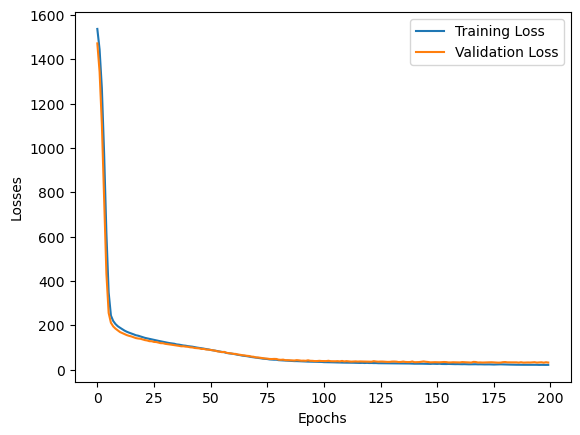

In [58]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [59]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [61]:
# Evaluation

model.eval()
with torch.no_grad():
    train_pred = model(x_train_tensor)
    test_pred = model(x_test_tensor)

    train_mse_loss = crietrion(train_pred,x_train_tensor)
    test_mse_loss = crietrion(test_pred,x_test_tensor)


print("train mse :",train_mse_loss.item())
print("test mse :",test_mse_loss.item())

train mse : 1618.6787109375
test mse : 1530.1461181640625


C:\Users\prith\anaconda3\envs\torch_env\lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([824, 8])) that is different to the input size (torch.Size([824, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
C:\Users\prith\anaconda3\envs\torch_env\lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([206, 8])) that is different to the input size (torch.Size([206, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [62]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_pred))

r^2 score = 0.8720856514398574


In [63]:
predicted_df = pd.DataFrame(test_pred.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,45.821377,52.91
1,45.150623,55.90
2,69.349747,74.50
3,41.131721,35.30
4,13.431426,10.54
...,...,...
201,58.988110,56.14
202,21.905710,18.75
203,42.464596,38.00
204,67.804558,74.36
